In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!wget -q https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!tar -xzf flower_photos.tgz -C /kaggle/working/

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import os

In [4]:
# Hyperparameters defined in the reference notebook
EPOCHS = 50
BATCH_SIZE = 64
LEARNING_RATE = 0.001
INPUT_SIZE = 224

In [5]:
# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


VGG16 requires images to be resized to 224x224 pixels. Additionally, the reference notebook introduces data augmentation during training

Resize: Standardizes all images to 224x224

RandomHorizontalFlip: Randomly flips the images horizontally. This is a data augmentation technique that prevents overfitting by forcing the model to learn features regardless of their orientation

ToTensor & Normalize: Converts the images into PyTorch tensors and normalizes them using ImageNet standards (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]).

In [6]:
# Data transformations including RandomHorizontalFlip for augmentation
transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [7]:
# Load the full extracted dataset
data_dir = "/kaggle/working/flower_photos"
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

In [8]:
# Split 80% for training, 20% for validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [9]:
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [10]:
print(f"Training images: {len(train_dataset)} | Validation images: {len(val_dataset)}")

Training images: 2936 | Validation images: 734


We load the pretrained vgg16 model.

In [11]:
# Load Pretrained VGG16
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 212MB/s]  


We freeze all the convolutional layers inside model.features by setting requires_grad = False. These layers already know how to detect edges, textures, and shapes.

In [12]:
# Freeze feature extraction layers
for param in model.features.parameters():
    param.requires_grad = False

We completely replace the model.classifier block with a new nn.Sequential block. The input feature size coming from VGG16's convolutions is massive: 25088 features. This flows through intermediate linear layers of size 4096, accompanied by ReLU activations and Dropout for regularization.

The final nn.Linear layer outputs exactly 5 classes to match your dataset

In [13]:
# Replace the classifier to handle 25088 input features and 5 output classes
model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(inplace=True),
    nn.Dropout(),
    nn.Linear(4096, 4096),
    nn.ReLU(inplace=True),
    nn.Dropout(),
    nn.Linear(4096, 5)  
)

We unfreeze only the last layer (model.classifier[-1]) so it can learn to map those features to your 5 specific flowers

In [14]:
# Unfreeze the final classifier layer
for param in model.classifier[-1].parameters():
    param.requires_grad = True

In [15]:
# Check if more than 1 GPU is available, and wrap the model in DataParallel
if torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

Let's use 2 GPUs!


In [16]:
# Move model to GPU
model = model.to(device)

In [17]:
# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

Training (model.train()): Computes gradients, updates weights, and prints progress every 10 batches.

Validation (model.eval()): Disables gradient calculation (torch.no_grad()) to quickly check how well the model is generalizing to unseen data.

it saves the loss and accuracy metrics into a local history dictionary so you can plot them later.

In [18]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs=10):
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        model.train()
        train_correct = 0
        train_total = 0
        running_loss = 0.0

        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 30)

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            batch_correct = (preds == labels).sum().item()
            train_correct += batch_correct
            train_total += labels.size(0)

            # Print every 10 batches
            if (i + 1) % 10 == 0:
                batch_acc = batch_correct / labels.size(0)
                print(f"[Batch {i+1}/{len(train_loader)}] Loss: {loss.item():.4f}, Batch Acc: {batch_acc:.4f}")

        train_acc = train_correct / train_total
        print(f"Epoch {epoch+1} Summary - Loss: {running_loss:.4f}, Train Accuracy: {train_acc:.4f}")

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        print(f"Validation Accuracy: {val_acc:.4f}")
        
        # Save metrics locally instead of wandb
        history['train_loss'].append(running_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
    return history

In [19]:
# Train the model
history = train_model(model, criterion, optimizer, train_loader, val_loader, epochs=EPOCHS)


Epoch 1/50
------------------------------
[Batch 10/46] Loss: 0.7883, Batch Acc: 0.6875
[Batch 20/46] Loss: 0.3646, Batch Acc: 0.8594
[Batch 30/46] Loss: 0.5770, Batch Acc: 0.7812
[Batch 40/46] Loss: 0.3959, Batch Acc: 0.8438
Epoch 1 Summary - Loss: 74.3195, Train Accuracy: 0.7129
Validation Accuracy: 0.8678

Epoch 2/50
------------------------------
[Batch 10/46] Loss: 0.3305, Batch Acc: 0.9062
[Batch 20/46] Loss: 0.2740, Batch Acc: 0.8750
[Batch 30/46] Loss: 0.3604, Batch Acc: 0.8438
[Batch 40/46] Loss: 0.2257, Batch Acc: 0.9375
Epoch 2 Summary - Loss: 14.6260, Train Accuracy: 0.8975
Validation Accuracy: 0.8951

Epoch 3/50
------------------------------
[Batch 10/46] Loss: 0.4139, Batch Acc: 0.9531
[Batch 20/46] Loss: 0.2940, Batch Acc: 0.9062
[Batch 30/46] Loss: 0.4118, Batch Acc: 0.8750
[Batch 40/46] Loss: 0.1751, Batch Acc: 0.9375
Epoch 3 Summary - Loss: 10.8660, Train Accuracy: 0.9264
Validation Accuracy: 0.8651

Epoch 4/50
------------------------------
[Batch 10/46] Loss: 0.21

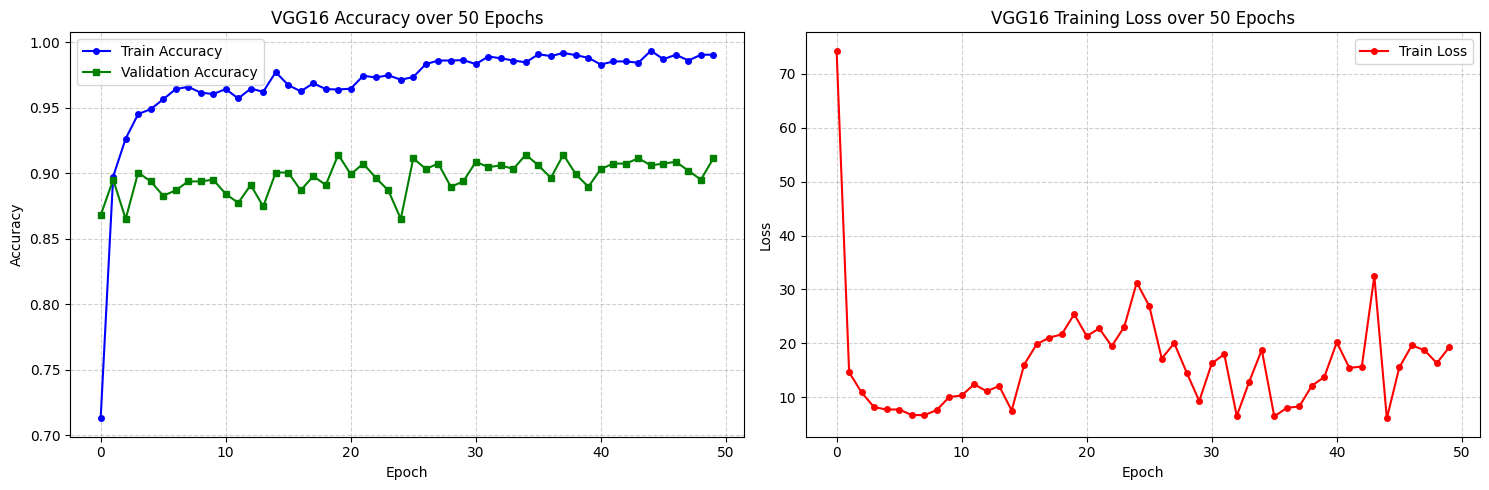

In [20]:
import matplotlib.pyplot as plt

# Create a 1x2 grid for the plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Plot Accuracy
axes[0].plot(history['train_acc'], label='Train Accuracy', color='blue', marker='o', markersize=4)
axes[0].plot(history['val_acc'], label='Validation Accuracy', color='green', marker='s', markersize=4)
axes[0].set_title('VGG16 Accuracy over 50 Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Plot Loss
axes[1].plot(history['train_loss'], label='Train Loss', color='red', marker='o', markersize=4)
axes[1].set_title('VGG16 Training Loss over 50 Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [21]:
# Save the trained weights to the Kaggle working directory
save_path = '/kaggle/working/vgg16_5flowers_model.pth'
torch.save(model.state_dict(), save_path)
print(f"Model weights successfully saved to {save_path}")

Model weights successfully saved to /kaggle/working/vgg16_5flowers_model.pth


In [22]:
import random

# Get the list of class names (daisy, dandelion, roses, sunflowers, tulips)
class_names = full_dataset.classes


In [23]:
# Ensure the model is in evaluation mode
model.eval()

DataParallel(
  (module): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      

In [24]:
# Select a random image from the validation dataset
random_idx = random.randint(0, len(val_dataset) - 1)
image_tensor, actual_label_idx = val_dataset[random_idx]

In [25]:
# Add a batch dimension: (C, H, W) becomes (1, C, H, W) and send to GPU
image_batch = image_tensor.unsqueeze(0).to(device)

In [26]:
# Perform inference
with torch.no_grad():
    output = model(image_batch)
    # Get the index of the highest predicted probability
    _, predicted_idx = torch.max(output, 1)

In [27]:
# Extract the string names for the labels
actual_flower = class_names[actual_label_idx]
predicted_flower = class_names[predicted_idx.item()]

In [28]:
# Un-normalize the image so it looks normal when plotted
image_display = image_tensor.permute(1, 2, 0).numpy()
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image_display = std * image_display + mean
image_display = image_display.clip(0, 1) # Ensure pixel values are between 0 and 1

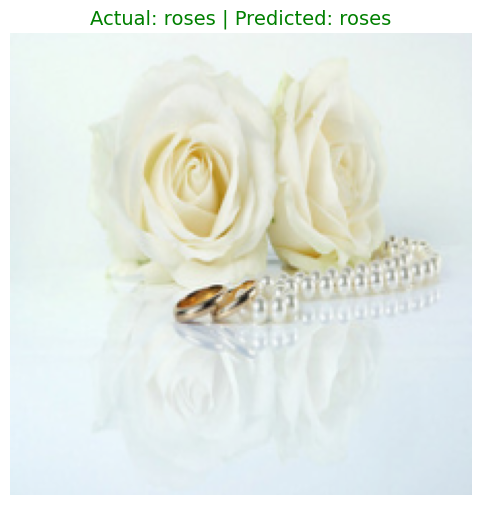

In [31]:
# Plot the image and the prediction
plt.figure(figsize=(6, 6))
plt.imshow(image_display)
# Color the title green if correct, red if incorrect
title_color = "green" if actual_flower == predicted_flower else "red"
plt.title(f"Actual: {actual_flower} | Predicted: {predicted_flower}", color=title_color, fontsize=14)
plt.axis('off')
plt.show()